# Trabalho Fundamento em Ciência de Dados
## Tema: Análise do histórico e correlação do Bitcoin
### Alunos
- Predo Henrique Covisi; RA:
- Lucca Teodoro Vaz; RA: 18119311

### Instruções para Trabalho
1) Descrição do problema e dos dados
-  Apresentar o tema escolhido;
- Descrever a origem da base de dados;
- Explicar os objetivos ou perguntas que serão investigadas.
2) Preparação dos dados
- Identificar e tratar valores ausentes ou inconsistentes;
- Remover duplicidades, quando necessário;
- Descrever as etapas de limpeza e pré-processamento dos dados.
3) Análise exploratória dos dados
Realizar análises utilizando tabelas e gráficos para responder às perguntas propostas.
Exemplos:
- Distribuiçao das variáveis;
- Comparaçao entre grupos;
- Associaçoes entre variáveis;
- Identificação de padrões ou tendências.
Devem ser utilizados pelo menos três tipos diferentes de visualizaçao de dados, como his-
togramas, gráficos de barras, gráficos de disperssão, boxplots, entre outros.
4) Resultados e conclusões
- Apresentar os principais resultados encontrados;
- Discutir possíveis limitações da base de dados;
- Destacar conclusões e aplicações do estudo

## 1) Descrição do Problema e dos dado

#### 1a) Apresentar o tema escolhido:
O tema escolhido foi a análise do histórico e da correlação do Bitcoin com outros ativos financeiros. Assim, nosso objetivo é fazer uma análise profunda da cotação do Bitcoin e da sua correlação, que mudou ao longo dos anos, com outros ativos financeiros relevantes, como o Petróleo, Bolsas Americana e Brasileria, Ouro, Etherium ( segunda maior criptomoeda ), Titulos do Tesouro, entre outros. Escolhemos esse tema devido ao grande interesse que temos no mercado financeiro e na influência que o Bitcoin, e outras criptomoedas, vem ganhando com o passar do tempo.

#### 1b) Descrever a Origim da base de dados


#### 1c) Explicar os objetivos ou perguntas que serão investigadas
1) Fornecer uma breve contextualização sobre o Bitcoin
2) Fazer observações com relação ao preço do bictoin  ( como volatidade, drawdown entre outros )
3) Analisar a correlação do Bitcoin com outros ativos financeiros
4) Representar essa correlação de forma gráfica e matemática
5) Tentar realizar previsões relativas a cotação do Bitcoin com base em seu histórico e correlação com outros ativos financeiros

## 2) Preparação dos Dados

### 1) Importação e limpeza dos dados dos ativos financeiros

Importando as bilbiotecas

In [68]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

Importando os dados financeiros do Yahoo Finance

In [69]:
#Primeiro colocamos os tickers que serão importados em uma lista 
tickers_ativos = [
    "BTC-USD", #Bitcoin
    "ETH-USD", #Etherium
    "^GSPC", #S&P 500
    "^IXIC", #Nasdaq
    "^BVSP", #Bovespa
    "GC=F", #Ouro 
    "CL=F", #Petróleo
    "DX-Y.NYB", #Dólar
]

#Agora fazemos o donwload dos dados desses ativos tra
df_ativos = yf.download(tickers_ativos, start="2020-01-01")

#Filtrando apenas as 4 métricas desejadas
metricas_desejadas = ['Open', 'High', 'Low', 'Close']
df_filtrado = df_ativos[metricas_desejadas]

df_ativos = df_filtrado
df_ativos.head(20)

[*********************100%***********************]  8 of 8 completed


Price              Open                                                 \
Ticker          BTC-USD       CL=F   DX-Y.NYB     ETH-USD         GC=F   
Date                                                                     
2020-01-01  7194.892090        NaN        NaN  129.630661          NaN   
2020-01-02  7202.551270  61.599998  96.480003  130.820038  1518.099976   
2020-01-03  6984.428711  61.180000  96.790001  127.411263  1530.099976   
2020-01-04  7345.375488        NaN        NaN  134.168518          NaN   
2020-01-05  7410.451660        NaN        NaN  135.072098          NaN   
2020-01-06  7410.452148  63.709999  96.900002  136.305542  1580.000000   
2020-01-07  7768.682129  62.910000  96.650002  144.311996  1558.300049   
2020-01-08  8161.935547  62.840000  96.830002  143.487823  1579.699951   
2020-01-09  8082.295898  59.990002  97.269997  141.155777  1555.699951   
2020-01-10  7878.307617  59.610001  97.430000  138.967041  1551.199951   
2020-01-11  8162.190918        NaN        NaN  143.409103          NaN   
2020-01-12  8033.261719        NaN        NaN  143.032547          NaN   
2020-01-13  8189.771973  59.040001  97.349998  146.220139  1557.400024   
2020-01-14  8140.933105  58.029999  97.360001  144.251053  1546.699951   
2020-01-15  8825.343750  58.200001  97.379997  165.734619  1548.000000   
2020-01-16  8812.481445  58.099998  97.180000  166.332825  1555.699951   
2020-01-17  8725.209961  58.590000  97.309998  164.489380  1554.099976   
2020-01-18  8927.211914        NaN        NaN  170.747726          NaN   
2020-01-19  8941.445312        NaN        NaN  175.467590          NaN   
2020-01-20  8704.631836        NaN        NaN  166.904129          NaN   

Price                                                  High             ...  \
Ticker         ^BVSP        ^GSPC        ^IXIC      BTC-USD       CL=F  ...   
Date                                                                    ...   
2020-01-01       NaN          NaN          NaN  7254.330566        NaN  ...   
2020-01-02  115652.0  3244.669922  9039.459961  7212.155273  61.599998  ...   
2020-01-03  118564.0  3226.360107  8976.429688  7413.715332  64.089996  ...   
2020-01-04       NaN          NaN          NaN  7427.385742        NaN  ...   
2020-01-05       NaN          NaN          NaN  7544.497070        NaN  ...   
2020-01-06  117707.0  3217.550049  8943.500000  7781.867188  64.720001  ...   
2020-01-07  116872.0  3241.860107  9076.639648  8178.215820  63.150002  ...   
2020-01-08  116667.0  3238.590088  9068.030273  8396.738281  65.650002  ...   
2020-01-09  116248.0  3266.030029  9202.269531  8082.295898  60.310001  ...   
2020-01-10  115948.0  3281.810059  9232.950195  8166.554199  59.779999  ...   
2020-01-11       NaN          NaN          NaN  8218.359375        NaN  ...   
2020-01-12       NaN          NaN          NaN  8200.063477        NaN  ...   
2020-01-13  115503.0  3271.129883  9213.719727  8197.788086  59.270000  ...   
2020-01-14  117325.0  3285.350098  9270.610352  8879.511719  58.720001  ...   
2020-01-15  117632.0  3282.270020  9253.759766  8890.117188  58.360001  ...   
2020-01-16  116415.0  3302.969971  9313.450195  8846.460938  58.869999  ...   
2020-01-17  116710.0  3323.659912  9392.370117  8958.122070  58.980000  ...   
2020-01-18       NaN          NaN          NaN  9012.198242        NaN  ...   
2020-01-19       NaN          NaN          NaN  9164.362305        NaN  ...   
2020-01-20  118478.0          NaN          NaN  8745.590820        NaN  ...   

Price               Low                     Close                        \
Ticker            ^GSPC        ^IXIC      BTC-USD       CL=F   DX-Y.NYB   
Date                                                                      
2020-01-01          NaN          NaN  7200.174316        NaN        NaN   
2020-01-02  3235.530029  9010.889648  6985.470215  61.180000  96.849998   
2020-01-03  3222.340088  8976.429688  7344.884277  63.049999  96.839996   
2020-01-04          NaN      

Mudando nome das colunas para torna-las mais legíveis 

In [70]:
df_ativos = df_ativos.rename(columns={
    '^BVSP': 'Bovespa',
    'BTC-USD': 'Bitcoin',
    'ETH-USD': 'Etherium',
    '^GSPC': 'SP500',
    '^IXIC': 'Nasdaq',
    'CL=F': 'Petróleo',
    'GC=F': 'Ouro',
    'DX-Y.NYB' : 'Dólar'
})

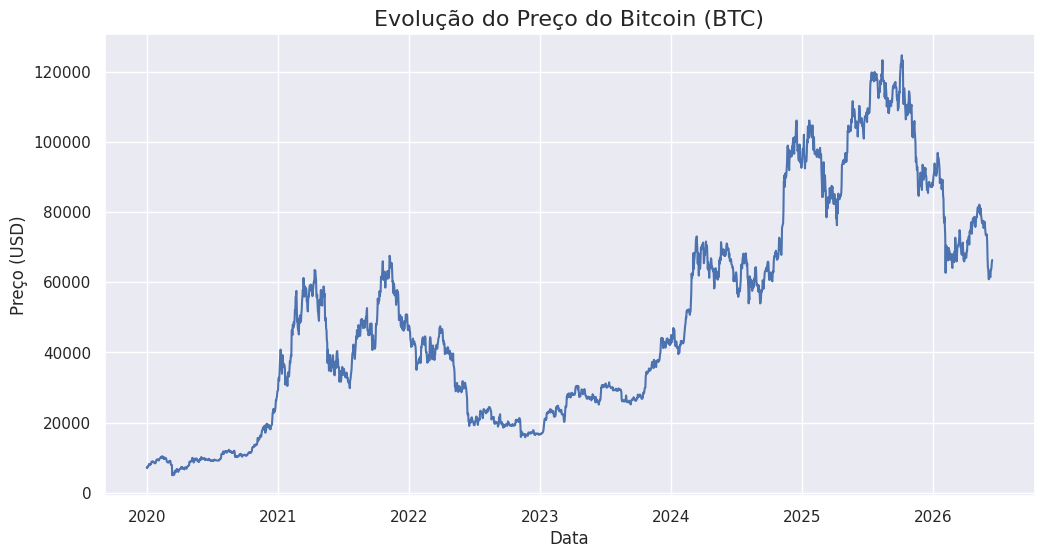

In [71]:
btc_close = df_ativos[('Close','Bitcoin')].reset_index(name = 'Bitcoin')

sns.set_theme(style='darkgrid')
plt.figure(figsize=(12,6))

sns.lineplot(x='Date', y='Bitcoin', data=btc_close)

plt.title('Evolução do Preço do Bitcoin (BTC)', fontsize=16)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço (USD)', fontsize=12)

plt.show()

### 2) Verificação de dados faltantes

In [72]:
# Verificação dos dados faltantes
dados = df_ativos
dados.isna().sum() #Conta número de dados faltantes e imprime os resultados

Price  Ticker  
Open   Bitcoin       0
       Petróleo    735
       Dólar       735
       Etherium      0
       Ouro        735
       Bovespa     753
       SP500       737
       Nasdaq      737
High   Bitcoin       0
       Petróleo    735
       Dólar       735
       Etherium      0
       Ouro        735
       Bovespa     753
       SP500       737
       Nasdaq      737
Low    Bitcoin       0
       Petróleo    735
       Dólar       735
       Etherium      0
       Ouro        735
       Bovespa     753
       SP500       737
       Nasdaq      737
Close  Bitcoin       0
       Petróleo    735
       Dólar       735
       Etherium      0
       Ouro        735
       Bovespa     753
       SP500       737
       Nasdaq      737
dtype: int64

A partir dessa verificação apesentam-se vários dados faltantes, os quais ja eram esperados. Isso porque, diferetemente dos mercados tradicionais o bitcoin e o etherium são negociados de fim de semana e nos feriados.

Assim, para analisar a correlação entre o bitcoin e outros ativos ( exceto o eth ), existem duas opções:
1) Adicionamos, artificialmente, os dados do fechamento do dia anterior para os dias com dados faltantes, para os ativos financeiros tradicionais
2) Ou Excluimos os dados de Bitcoin e do Etherium nos fim de semanas e feriados

Para deixar a análise de correlação a mais acertiva possível, optamos pela segunda opção. Mas antes vamos copiar as colunas relativas ao etherium e ao bitcoin para poder realizar análises mais acertivas entre as criptomoedas sem perder os dados do fim de semana

In [74]:
df_ativos

Price               Open                                                   \
Ticker           Bitcoin   Petróleo       Dólar     Etherium         Ouro   
Date                                                                        
2020-01-01   7194.892090        NaN         NaN   129.630661          NaN   
2020-01-02   7202.551270  61.599998   96.480003   130.820038  1518.099976   
2020-01-03   6984.428711  61.180000   96.790001   127.411263  1530.099976   
2020-01-04   7345.375488        NaN         NaN   134.168518          NaN   
2020-01-05   7410.451660        NaN         NaN   135.072098          NaN   
...                  ...        ...         ...          ...          ...   
2026-06-11  61448.878906  92.250000  100.120003  1620.140015  4042.899902   
2026-06-12  63547.441406  86.639999   99.669998  1671.818970  4208.299805   
2026-06-13  63541.515625        NaN         NaN  1665.048706          NaN   
2026-06-14  64420.167969        NaN         NaN  1680.146484          NaN   
2026-06-15  65710.093750  81.400002   99.536003  1724.435913  4289.399902   

Price                                                         High             \
Ticker            Bovespa        SP500        Nasdaq       Bitcoin   Petróleo   
Date                                                                            
2020-01-01            NaN          NaN           NaN   7254.330566        NaN   
2020-01-02  115652.000000  3244.669922   9039.459961   7212.155273  61.599998   
2020-01-03  118564.000000  3226.360107   8976.429688   7413.715332  64.089996   
2020-01-04            NaN          NaN           NaN   7427.385742        NaN   
2020-01-05            NaN          NaN           NaN   7544.497070        NaN   
...                   ...          ...           ...           ...        ...   
2026-06-11  168619.000000  7287.669922  25309.779297  63851.949219  93.639999   
2026-06-12  171497.000000  7410.850098  25783.359375  64334.015625  87.230003   
2026-06-13            NaN          NaN           NaN  64700.878906        NaN   
2026-06-14            NaN          NaN           NaN  65749.781250        NaN   
2026-06-15  171139.109375  7516.750000  26447.230469  66858.914062  82.419998   

Price       ...          Low                       Close             \
Ticker      ...        SP500        Nasdaq       Bitcoin   Petróleo   
Date        ...                                                       
2020-01-01  ...          NaN           NaN   7200.174316        NaN   
2020-01-02  ...  3235.530029   9010.889648   6985.470215  61.180000   
2020-01-03  ...  3222.340088   8976.429688   7344.884277  63.049999   
2020-01-04  ...          NaN           NaN   7410.656738        NaN   
2020-01-05  ...          NaN           NaN   7411.317383        NaN   
...         ...          ...           ...           ...        ...   
2026-06-11  ...  7257.330078  25109.390625  63561.054688  87.709999   
2026-06-12  ...  7363.009766  25599.939453  63543.199219  84.879997   
2026-06-13  ...          NaN           NaN  64421.324219        NaN   
2026-06-14  ...          NaN           NaN  65710.398438        NaN   
2026-06-15  ...  7516.750000  26438.767578  66362.898438  80.260002   

Price                                                                        \
Ticker          Dólar     Etherium         Ouro        Bovespa        SP500   
Date                                                                          
2020-01-01        NaN   130.802002          NaN            NaN          NaN   
2020-01-02  96.849998   127.410179  1524.500000  118573.000000  3257.850098   
2020-01-03  96.839996   134.171707  1549.199951  117707.000000  3234.850098   
2020-01-04        NaN   135.069366          NaN            NaN          NaN   
2020-01-05        NaN   136.276779          NaN            NaN          NaN   
...               ...          ...          ...            ...          ...   
2026-06-11  99.860001  1672.280640  4090.300049  171497.000000  7394.299805   
2

In [80]:
df_btc = df_ativos.xs('Bitcoin', level=1, axis=1).copy()
df_btc

Price,Open,High,Low,Close
Date,,,,
2020-01-01,7194.892090,7254.330566,7174.944336,7200.174316
2020-01-02,7202.551270,7212.155273,6935.270020,6985.470215
2020-01-03,6984.428711,7413.715332,6914.996094,7344.884277
2020-01-04,7345.375488,7427.385742,7309.514160,7410.656738
2020-01-05,7410.451660,7544.497070,7400.535645,7411.317383
...,...,...,...,...
2026-06-11,61448.878906,63851.949219,61447.968750,63561.054688
2026-06-12,63547.441406,64334.015625,62778.792969,63543.199219
2026-06-13,63541.515625,64700.878906,63431.320312,64421.324219


In [82]:
df_eth = df_ativos.xs('Etherium', level=1, axis=1).copy()
df_eth

Price,Open,High,Low,Close
Date,,,,
2020-01-01,129.630661,132.835358,129.198288,130.802002
2020-01-02,130.820038,130.820038,126.954910,127.410179
2020-01-03,127.411263,134.554016,126.490021,134.171707
2020-01-04,134.168518,136.052719,133.040558,135.069366
2020-01-05,135.072098,139.410202,135.045624,136.276779
...,...,...,...,...
2026-06-11,1620.140015,1690.448853,1620.084473,1672.280640
2026-06-12,1671.818970,1689.444336,1650.628662,1665.127808
2026-06-13,1665.048706,1693.603271,1661.609131,1680.214600


Em relação ao maior número de dados faltante das bolsas em relação as commodities, já que esse número é pequeno, resolvemos relevar e excluir as observações mesmo assim

Agora, a exclusão de dados faltantes

In [84]:
dados.dropna(inplace=True) 
dados.isna().sum() 

Price  Ticker  
Open   Bitcoin     0
       Petróleo    0
       Dólar       0
       Etherium    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
High   Bitcoin     0
       Petróleo    0
       Dólar       0
       Etherium    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
Low    Bitcoin     0
       Petróleo    0
       Dólar       0
       Etherium    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
Close  Bitcoin     0
       Petróleo    0
       Dólar       0
       Etherium    0
       Ouro        0
       Bovespa     0
       SP500       0
       Nasdaq      0
dtype: int64

## 3) Análise Exploratória de Dados

## 1) Análises Bitcoin

### 1) Sazonalidade:
#### Como os dias da semana afetam os movimentos nos preços do Bitcoin ?

In [86]:
df_btc_close = df_btc['Close'].reset_index(name='Cotação')
df_btc_close

,Date,Cotação
0,2020-01-01,7200.174316
1,2020-01-02,6985.470215
2,2020-01-03,7344.884277
3,2020-01-04,7410.656738
4,2020-01-05,7411.317383
...,...,...
2353,2026-06-11,63561.054688
2354,2026-06-12,63543.199219
2355,2026-06-13,64421.324219
2356,2026-06-14,65710.398438
